# Анализ данных GPS-телеметрии

**Подготовил:** Стукалов Артем Витальевич  
**Дата:** 09.07.2026

## Описание задачи

Разработать скрипт для анализа данных GPS-телеметрии транспортных средств для автоматизации отчётности по пробегу и топливу. 
Исходные данные — Excel-файл с двумя листами:
- **GPS_данные** — телеметрия (ТС, дата/время, координаты, скорость, обороты, уровень топлива)
- **Нормативы** — справочник норм расхода топлива по режимам (город/трасса/холостой ход)

## Задание 1. Разведка и очистка данных

Импортируем основные библиотеки для дальнейшего анализа данных

In [1]:
import numpy as np
import pandas as pd # Импортируем библиотеку pandas

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

# Загружаем библиотеки для математических вычислений
from math import radians, sin, cos, sqrt, atan2

Загрузим данные excel таблицы в переменную df.

In [2]:
# Загружаем оба листа в отдельные датасеты
df = pd.read_excel('Исходные данные.xlsx', sheet_name='GPS_данные')
df_norm = pd.read_excel('Исходные данные.xlsx', sheet_name='Нормативы')

Познакомимся с данными датасета df

In [3]:
print(df.head().to_string(index=False)) # Выводим первые строки датасета с «GPS_данными» - сырые данные телеметрии 

            ТС        Дата и время        Широта       Долгота  Скорость  Обороты  Уровень топлива
FAW С - р232ох 10.06.2026 08:25:00 52° 37.34755' 39° 36.96808'      70.3   1415.0            338.6
FAW С - р232ох 10.06.2026 08:25:21 52° 37.26641' 39° 36.88709'      58.7   1799.0            338.5
FAW С - р232ох 10.06.2026 08:25:58 52° 37.18682' 39° 36.80086'      63.2   1409.0            338.4
FAW С - р232ох 10.06.2026 08:26:32 52° 37.10776' 39° 36.72724'      73.1   1707.0            338.3
FAW С - р232ох 10.06.2026 08:27:12 52° 37.01585' 39° 36.64751'      64.8   1589.0            338.2


In [4]:
df.info() # Выводим информацию о датасете df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8072 entries, 0 to 8071
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ТС               8072 non-null   object 
 1   Дата и время     8072 non-null   object 
 2   Широта           8072 non-null   object 
 3   Долгота          8072 non-null   object 
 4   Скорость         8072 non-null   float64
 5   Обороты          8064 non-null   float64
 6   Уровень топлива  8072 non-null   float64
dtypes: float64(3), object(4)
memory usage: 441.6+ KB


Создадим копию датасета для оценки итогов предобработки данных в дальнейшем.

In [5]:
initial_rows = df.copy() # создаем копию датасета с данными телеметрии
print(f'Количество строк в датасете до предобработки: {len(initial_rows)}')

Количество строк в датасете до предобработки: 8072


Посмотримся с данными датасета df_norm, который содержит «нормативы» — нормы расхода топлива для разных режимов работы

In [6]:
df_norm.head(10) # Выводим первые строки датасета нормативов

,ТС,Норма_город,Норма_трасса,Норма_холостой
0,Камаз КДМ - р671ос,25.9,13.9,2.2
1,МАЗ Т - к227рх,30.8,16.5,2.6
2,FAW С - р232ох,21.0,11.2,1.8
3,Shacman Т - р985мн,30.8,16.5,2.6
4,Камаз С - м952тв,21.0,11.2,1.8
5,МАЗ Т - е017сс,30.8,16.5,2.6
6,Shacman Т - р159ов,30.8,16.5,2.6


In [7]:
df_norm.info() #  Выводим информацию о датасете с нормативами

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ТС              7 non-null      object 
 1   Норма_город     7 non-null      float64
 2   Норма_трасса    7 non-null      float64
 3   Норма_холостой  7 non-null      float64
dtypes: float64(3), object(1)
memory usage: 356.0+ bytes


Как можно увидеть датасет df_norm не требует предобработки, поскольку представляет собой таблицу-справочник

**Пустые строки между данными**

Поскольку только текстовые колонки (тип object) могут содержать пробелы, избавимся от пробелов.

In [8]:
# Фильтруем текстовый тип данных
text_cols = df.select_dtypes(include=['object']).columns

# Удаляем возможные пробелы в словах
df[text_cols] = df[text_cols].apply(lambda x: x.str.strip())

# Заменим пустые строки на NaN
df = df.replace('', pd.NA)

**Некорректные даты (не соответствующие формату ДД.ММ.ГГГГ ЧЧ:ММ:СС)**

Выведем тип значений у столбцов текущего датасета.

In [9]:
# выводим типы данных
print(df.dtypes)

ТС                  object
Дата и время        object
Широта              object
Долгота             object
Скорость           float64
Обороты            float64
Уровень топлива    float64
dtype: object


Как можно было увидеть столбец 'Дата и время' представлен в виде типа данных object, в то время как ему соответствует тип данных datetime.

In [10]:
# Заменяем все слеши на точки в столбце с датой
df['Дата и время'] = df['Дата и время'].str.replace('/', '.')

# Теперь преобразуем в datetime с нужным форматом
df['Дата и время'] = pd.to_datetime(df['Дата и время'], 
                                     format='%d.%m.%Y %H:%M:%S',
                                     errors='coerce')

In [11]:
# Проверяем некорректные даты
invalid_dates = df[df['Дата и время'].isna()]
invalid_dates_count = len(invalid_dates)
if invalid_dates_count > 0:
    print(f"Найдено некорректных дат: {invalid_dates_count}")
    df = df.dropna(subset=['Дата и время'])
else:
    print('Ошибки в датах отсутствуют')

Ошибки в датах отсутствуют


**Пропуски в данных**

Узнаем о распределении количества пропусков между столбцами в абсолютных значениях

In [12]:
df.isna().sum() # считаем абсолютное количество пропусков

ТС                 0
Дата и время       0
Широта             0
Долгота            0
Скорость           0
Обороты            8
Уровень топлива    0
dtype: int64

Теперь узнаем о распределении количества пропусков между столбцами в относительных значениях

In [13]:
df.isna().mean()*100 # считаем относительное количество пропусков

ТС                 0.000000
Дата и время       0.000000
Широта             0.000000
Долгота            0.000000
Скорость           0.000000
Обороты            0.099108
Уровень топлива    0.000000
dtype: float64

Выведем столбцы с пропусками.

In [14]:
# Фильтруем столбцы с пропусками
empty = df[df['Обороты'].isna()>0].sort_values(by='Уровень топлива', ascending=False)

# Выводим столбцы с пропусками
empty.head(8)

,ТС,Дата и время,Широта,Долгота,Скорость,Обороты,Уровень топлива
2026,Shacman Т - р159ов,2026-06-10 13:01:21,52° 12.73256',39° 38.91809',0.0,NaN,414.0
2866,Shacman Т - р985мн,2026-06-10 10:26:28,52° 30.83312',39° 37.15181',62.4,NaN,398.0
7400,МАЗ Т - к227рх,2026-06-10 12:44:56,52° 33.72260',39° 17.63213',0.0,NaN,377.9
7420,МАЗ Т - к227рх,2026-06-10 12:54:43,52° 33.73313',39° 17.00494',64.1,NaN,375.3
164,FAW С - р232ох,2026-06-10 09:48:16,52° 25.34502',39° 24.59211',63.6,NaN,324.7
4241,Камаз КДМ - р671ос,2026-06-10 14:31:40,52° 41.44240',39° 4.03231',0.0,NaN,311.6
3435,Shacman Т - р985мн,2026-06-10 15:07:26,52° 18.28699',39° 43.07902',30.2,NaN,307.3
5625,Камаз С - м952тв,2026-06-10 12:58:41,52° 58.39422',38° 50.44097',53.6,NaN,182.4


Поскольку пропуски в данных составляют менее 1%, в таком случае целесообразно будет удалить данные столбцы с пропусками.

In [15]:
# Удаляем все строки, где столбец 'Обороты' равна NaN
df = df.dropna(subset=['Обороты'])
print(f'Удалено строк: {len(initial_rows) - len(df)}')

Удалено строк: 8


**Дубликаты строк**

Посчитаем количество полных дубликатов.

In [16]:
# Ищем явные дубликаты
full_duplicates_rows = df.duplicated().sum()  # количество дублированных строк
full_duplicates_groups  = df[df.duplicated(keep=False)]

print(f'Количество дублированных строк в датасете df: {full_duplicates_rows}')
print(f'Количество строк в группах дубликатов: {len(full_duplicates_groups)}') 

Количество дублированных строк в датасете df: 3
Количество строк в группах дубликатов: 6


Выведем полные дубликаты

In [17]:
# Выводим полные дубликаты
print(full_duplicates_groups.head(6).to_string(index=False))

                ТС        Дата и время        Широта       Долгота  Скорость  Обороты  Уровень топлива
Камаз КДМ - р671ос 2026-06-10 13:55:27 52° 41.00518'  39° 6.71881'      78.4   1892.0            321.0
Камаз КДМ - р671ос 2026-06-10 13:55:27 52° 41.00518'  39° 6.71881'      78.4   1892.0            321.0
Камаз КДМ - р671ос 2026-06-10 18:56:16 52° 44.35869' 38° 46.01130'      50.1   1588.0            256.8
Камаз КДМ - р671ос 2026-06-10 18:56:16 52° 44.35869' 38° 46.01130'      50.1   1588.0            256.8
  Камаз С - м952тв 2026-06-10 12:26:22 52° 55.42229' 38° 56.01489'      58.4   1755.0            188.7
  Камаз С - м952тв 2026-06-10 12:26:22 52° 55.42229' 38° 56.01489'      58.4   1755.0            188.7


Удалим найденные дубликаты.

In [18]:
# Удаляем полные дубликаты
df.drop_duplicates(inplace=True)

# Проверяем результат
df.duplicated().sum()

np.int64(0)

Проверим таблицу на наличие неявных дубликатов на примере совпадения столбцов 'ТС' и 'Дата и время'

In [19]:
implicit_duplicates = df[df.duplicated(subset=['ТС', 'Дата и время'], keep=False)]
print(f'Найдено неявных дубликатов строк: {len(implicit_duplicates)}')

Найдено неявных дубликатов строк: 0


Как можно увидеть, неявные дубликаты отсутствуют.

Сделаем оценку проведённой предобработки датасета.

In [20]:
print(f'Количество строк в начальном датасете: {len(initial_rows)}')
print(f'Количество строк после предобработки данных: {len(df)}')
print(f'Потеряно данных: {len(initial_rows) - len(df)} строк ({(len(initial_rows) - len(df))/len(initial_rows)*100:.2f}%)')
print(f'Сохранено данных: {len(df)/len(initial_rows)*100:.2f}%')

Количество строк в начальном датасете: 8072
Количество строк после предобработки данных: 8061
Потеряно данных: 11 строк (0.14%)
Сохранено данных: 99.86%


### Промежуточный вывод по проверке ошибок в данных и их предобработке:
- **Исходные данные:**
    - **Лист `GPS_данные`**  загружен в датасет `df`: 8072 записи телеметрии (7 транспортных средств, одна дата - 10.06.2026).
    - **Лист `Нормативы`** загружен в датасет `df_norm`: справочник норм расхода топлива для каждого ТС в режимах «город», «трасса», «холостой ход».
    - Предобработка выполнялась только для датасета `df` (GPS-данные). Справочный датафрейм `df_norm` был проверен и не содержит пропусков, дубликатов или некорректных форматов, поэтому его структура и данные сохранены без изменений.
- **Пустые строки между данными:**
    - Выполнена очистка текстовых полей от возможных пробелов 
    - Пустые строки заменены на NaN
- **Некорректные даты:**
    - **Проблема:** c помощью параметра errors='raise' были обнаружены даты со слешами вместо точек.
    - **Решение:** выполнена замена '/' на '.'
    - **Проблема:** столбец 'Дата и время' имел тип object (строковый).
    - **Решение:** для корректной работы с временными рядами данный столбец был преобразован в datetime
- **Пропуски в данных:**
    - В столбце 'Обороты' найдено 8 пропусков (0.09%).
    - Поскольку количество пропусков менее 1% принято решение их удалить.
- **Дубликаты строк:**
    - Найдено 3 группы полных дубликатов (всего 6 строк затронуто дублированием).
    - Удалено 3 дублированных строки.
    - Неявные дубликаты не найдены.
- **Потерянные данные:**
    - Итоговое количество строк: 8061
    - Потеряно данных: 11 строк (0.14%)
    - Сохранено данных: 8061 строк (99.86%)

## Задание 2. Преобразование координат

Выведем столбцы с координатами.

In [21]:
print(df[['Широта', 'Долгота']].head()) # Смотрим значения столбцов с координатами

          Широта        Долгота
0  52° 37.34755'  39° 36.96808'
1  52° 37.26641'  39° 36.88709'
2  52° 37.18682'  39° 36.80086'
3  52° 37.10776'  39° 36.72724'
4  52° 37.01585'  39° 36.64751'


Координаты записаны в нестандартном формате: 52° 34.81193'. Напишите функцию, которая переводит их в десятичные градусы по формуле:
Десятичные градусы = градусы + минуты / 60.

In [22]:
# функция для преобразования координат
def convert_coordinates_to_decimal(coord_str):
    try:
        parts = str(coord_str).strip().split('°')
        degrees = float(parts[0].strip())
        minutes = float(parts[1].strip().replace("'", "").strip())
        return degrees + minutes / 60.0
    except:
        return None

df['Широта'] = df['Широта'].apply(convert_coordinates_to_decimal)
df['Долгота'] = df['Долгота'].apply(convert_coordinates_to_decimal)

print(df[['Широта', 'Долгота']].head())

      Широта    Долгота
0  52.622459  39.616135
1  52.621107  39.614785
2  52.619780  39.613348
3  52.618463  39.612121
4  52.616931  39.610792


### Промежуточный вывод по преобразованию координат:
- Разработана функция convert_coordinates_to_decimal, которая извлекает градусы и минуты, затем пересчитывает их по формуле.
- Функция применена к колонкам Широта и Долгота с использованием apply(), при этом обработка ошибок через try-except защищает от некорректных значений (в таких случаях возвращается None).

## Задание 3. Расчёт пробега

Напишем функцию для расчёта формулы гаверсинуса.

**Формула гаверсинуса:**  
a = sin²(Δlat/2) + cos(lat1) * cos(lat2) * sin²(Δlon/2)  
c = 2 * atan2(√a, √(1−a))  
d = R * c  
где R = 6371 км (радиус Земли), lat и lon — в радианах.

In [23]:
# Функция гаверсинуса
def haversine(lat1, lon1, lat2, lon2):
    # Переводим градусы в радианы
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # Подготавливаем значения для формулы (Δlat, Δlon)
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Делаем вычисления по формуле
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2

    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    d = 6371 * c
    return d

Считаем расстояние между соседними точками 

In [24]:
# Расчёт расстояний между соседними точками
# Сортируем данные
df = df.sort_values(['ТС', 'Дата и время']).reset_index(drop=True)

# Получаем координаты предыдущей точки для каждого ТС
df['prev_lat'] = df.groupby('ТС')['Широта'].shift(1)
df['prev_lon'] = df.groupby('ТС')['Долгота'].shift(1)

# Функция для вычисления расстояния
def get_distance(row):
    if pd.isna(row['prev_lat']):
        return 0.0
    return haversine(row['Широта'], row['Долгота'],
                     row['prev_lat'], row['prev_lon'])
df['Расстояние_до_предыдущей_км'] = df.apply(get_distance, axis=1)

# Удаляем временные столбцы с предыдущими координатами
df.drop(['prev_lat', 'prev_lon'], axis=1, inplace=True)

Посчитаем общий пробег за день для каждой машины

In [25]:
# Считаем общий пробег за день
df['Дневной_пробег'] = df.groupby(['ТС', df['Дата и время'].dt.date])['Расстояние_до_предыдущей_км'].transform('sum')

Посчитаем среднюю скорость движения (без учёта стоянок, то есть только для точек где Скорость > 0)

In [26]:
# Считаем среднюю скорость движения (только где скорость > 0)
df['Средняя_скорость'] = df.groupby(['ТС', df['Дата и время'].dt.date])['Скорость'].transform(
    lambda x: x[x > 0].mean()
)

In [27]:
# Выведем полученный результат
result = df[['ТС', 'Дата и время', 'Расстояние_до_предыдущей_км', 'Дневной_пробег', 'Средняя_скорость']]
print(result.head(10).to_string(index=False))

            ТС        Дата и время  Расстояние_до_предыдущей_км  Дневной_пробег  Средняя_скорость
FAW С - р232ох 2026-06-10 08:25:00                     0.000000      161.366473         54.960721
FAW С - р232ох 2026-06-10 08:25:21                     0.175825      161.366473         54.960721
FAW С - р232ох 2026-06-10 08:25:58                     0.176546      161.366473         54.960721
FAW С - р232ох 2026-06-10 08:26:32                     0.168311      161.366473         54.960721
FAW С - р232ох 2026-06-10 08:27:12                     0.192512      161.366473         54.960721
FAW С - р232ох 2026-06-10 08:27:44                     0.184309      161.366473         54.960721
FAW С - р232ох 2026-06-10 08:28:18                     0.181029      161.366473         54.960721
FAW С - р232ох 2026-06-10 08:28:41                     0.185544      161.366473         54.960721
FAW С - р232ох 2026-06-10 08:29:21                     0.179301      161.366473         54.960721
FAW С - р232ох 2026-

In [28]:
# Создаём столбей с датами
df['Дата'] = df['Дата и время'].dt.date

# Пробег по дням
daily_mileage_summary = df[['ТС', 'Дата', 'Дневной_пробег', 'Средняя_скорость']].drop_duplicates()

# Сортируем значения
daily_mileage_summary = daily_mileage_summary.sort_values('Дневной_пробег', ascending=False)

# Выводим дневной пробег и среднюю скорость за день по всем машинам
print('Дневной пробег и средняя скорость\n')
print(daily_mileage_summary.head(10).to_string(index=False))

Дневной пробег и средняя скорость

                ТС       Дата  Дневной_пробег  Средняя_скорость
    FAW С - р232ох 2026-06-10      161.366473         54.960721
  Камаз С - м952тв 2026-06-10       82.696610         53.162921
Shacman Т - р159ов 2026-06-10       80.142532         64.403689
Камаз КДМ - р671ос 2026-06-10       63.149850         55.774174
    МАЗ Т - к227рх 2026-06-10       42.113660         54.186231
Shacman Т - р985мн 2026-06-10       41.960248         45.850825
    МАЗ Т - е017сс 2026-06-10       39.636591         62.296863


### Промежуточный вывод по расчёту пробега:
- Расчёт расстояний между соседними точками выполнен с использованием формулы гаверсинуса. Для каждой строки определено расстояние до предыдущей точки (в км).
- Общий пробег за день рассчитан как сумма расстояний между соседними точками для каждой машины в рамках календарной даты. Полученные значения варьируются от 39.6 км (МАЗ Т - е017сс) до 161.4 км (FAW С - р232ох), что отражает разную интенсивность использования транспорта.
- Средняя скорость движения определена только по тем точкам, где скорость > 0 (стоянки исключены). Средние значения лежат в диапазоне от 45.9 (Shacman Т - р985мн) до 64.4 км/ч (Shacman Т - р159ов), что соответствует реальным условиям эксплуатации.
- Анализ показывает, что наибольший пробег за день зафиксирован у автомобиля FAW С - р232ох (161.37 км) при средней скорости 54.96 км/ч, что может указывать на длительные маршруты. Наименьший пробег – у МАЗ Т - е017сс (39.64 км) при скорости 62.3 км/ч – вероятно, короткие поездки по трассе.

## Задание 4. Анализ расхода топлива

Определим режим движения машины

In [29]:
# Определяем режим движения
df['Режим'] = 'движение' # По умолчанию ставим режим'движение'
df.loc[(df['Скорость'] == 0) & (df['Обороты'] > 0), 'Режим'] = 'холостой' # определяем условия для холостого режима движения

Для каждого из режима движения определим тип трассы по скорости

In [30]:
df['Тип_трассы'] = None # Создаём столбец 'Тип_трассы' со значением None для всех строк
df.loc[df['Режим'] == 'движение', 'Тип_трассы'] = 'город' # Для всех движений по умолчанию ставим 'город'
df.loc[(df['Режим'] == 'движение') & (df['Скорость'] >= 60), 'Тип_трассы'] = 'трасса' # по условию перезаписываем 'город' на 'трасса'

Рассчитаем расход топлива за интервал 

In [31]:
# Создаём словарь с нормами расхода топлива для разных режимов работы
norm_idle = dict(zip(df_norm['ТС'], df_norm['Норма_холостой']))
norm_city = dict(zip(df_norm['ТС'], df_norm['Норма_город']))
norm_highway = dict(zip(df_norm['ТС'], df_norm['Норма_трасса']))

# Проверяем результат
print(f'Словарь значений норм расхода топлива для холостого режима: {norm_idle}')
print(f'\nСловарь значений норм расхода топлива для города: {norm_city}')
print(f'\nСловарь значений норм расхода топлива для трассы: {norm_highway}')

Словарь значений норм расхода топлива для холостого режима: {'Камаз КДМ - р671ос': 2.2, 'МАЗ Т - к227рх': 2.6, 'FAW С - р232ох': 1.8, 'Shacman Т - р985мн': 2.6, 'Камаз С - м952тв': 1.8, 'МАЗ Т - е017сс': 2.6, 'Shacman Т - р159ов': 2.6}

Словарь значений норм расхода топлива для города: {'Камаз КДМ - р671ос': 25.9, 'МАЗ Т - к227рх': 30.8, 'FAW С - р232ох': 21.0, 'Shacman Т - р985мн': 30.8, 'Камаз С - м952тв': 21.0, 'МАЗ Т - е017сс': 30.8, 'Shacman Т - р159ов': 30.8}

Словарь значений норм расхода топлива для трассы: {'Камаз КДМ - р671ос': 13.9, 'МАЗ Т - к227рх': 16.5, 'FAW С - р232ох': 11.2, 'Shacman Т - р985мн': 16.5, 'Камаз С - м952тв': 11.2, 'МАЗ Т - е017сс': 16.5, 'Shacman Т - р159ов': 16.5}


Считаем разницу в секундах между соседними точками, чтобы определить ∆t (разницу в секундах между соседними точками)

In [32]:
# сортируем датасет
df = df.sort_values(['ТС', 'Дата и время']).reset_index(drop=True)

# Считаем разницу между соседними точками
delta_t = df.groupby('ТС')['Дата и время'].diff().dt.total_seconds().fillna(0)

Создаём столбец в датасете с расходом топлива

In [33]:
df['Расход_интервал'] = 0.0 # Создаём столбец 'Расход_интервал' и заполняем нулями 

**Рассчитываем расход топлива за интервал для холостого хода по формуле:**  
- Расход = Норма_холостой × (∆t / 3600)

In [34]:
# Маска для холостого хода
mask_idle = df['Режим'] == 'холостой'

# Расчитываем расход топлива для холостого хода
df.loc[mask_idle, 'Расход_интервал'] = df.loc[mask_idle, 'ТС'].map(norm_idle) * (delta_t[mask_idle] / 3600)

**Рассчитываем расход топлива за интервал для города по формуле:**  
- Расход = Норма_город × (Обороты / 1500) × (∆t / 3600)

In [35]:
# Маска для движения в городе
mask_city = (df['Режим'] == 'движение') & (df['Тип_трассы'] == 'город')

# Расчитываем расход топлива для города
df.loc[mask_city, 'Расход_интервал'] = (
    df.loc[mask_city, 'ТС'].map(norm_city) * (df.loc[mask_city, 'Обороты'] / 1500) * (delta_t[mask_city] / 3600)
)

**Рассчитываем расход топлива за интервал для трассы по формуле:**  
- Эффективность = 1.0 − |Скорость − 65| / 100
- Расход = Норма_трасса × (Обороты / 1500) × Эффективность × (∆t / 3600)

In [36]:
# Маска для движения на трассе
mask_highway = (df['Режим'] == 'движение') & (df['Тип_трассы'] == 'трасса')

# Рассчитываем эффективность
efficiency = 1 - np.abs(df.loc[mask_highway, 'Скорость'] - 65) / 100

# Расчитываем расход топлива для трассы
df.loc[mask_highway, 'Расход_интервал'] = (
    df.loc[mask_highway, 'ТС'].map(norm_highway) * (df.loc[mask_highway, 'Обороты'] / 1500) * efficiency * (delta_t[mask_highway] / 3600)
)

# Выводим полученный результат
print(df[['ТС', 'Дата и время', 'Режим', 'Тип_трассы', 'Расход_интервал']].head(10).to_string(index=False))

            ТС        Дата и время    Режим Тип_трассы  Расход_интервал
FAW С - р232ох 2026-06-10 08:25:00 движение     трасса         0.000000
FAW С - р232ох 2026-06-10 08:25:21 движение      город         0.146918
FAW С - р232ох 2026-06-10 08:25:58 движение     трасса         0.106181
FAW С - р232ох 2026-06-10 08:26:32 движение     трасса         0.110625
FAW С - р232ох 2026-06-10 08:27:12 движение     трасса         0.131564
FAW С - р232ох 2026-06-10 08:27:44 движение      город         0.216409
FAW С - р232ох 2026-06-10 08:28:18 движение     трасса         0.102162
FAW С - р232ох 2026-06-10 08:28:41 движение     трасса         0.074319
FAW С - р232ох 2026-06-10 08:29:21 движение      город         0.282178
FAW С - р232ох 2026-06-10 08:29:48 движение     трасса         0.077778


Для каждой машины суммируем расчётный расход за день.

In [37]:
# Группируем по машине и дате и суммируем расход топлива за интервалы, чтобы получить расчётный расход за день
df['Расчётный_расход'] = df.groupby(['ТС', 'Дата'])['Расход_интервал'].transform('sum')

# Выводим полученный результат
print(df[['ТС', 'Дата и время', 'Режим', 'Тип_трассы', 'Расчётный_расход']].head(10).to_string(index=False))

            ТС        Дата и время    Режим Тип_трассы  Расчётный_расход
FAW С - р232ох 2026-06-10 08:25:00 движение     трасса        138.471079
FAW С - р232ох 2026-06-10 08:25:21 движение      город        138.471079
FAW С - р232ох 2026-06-10 08:25:58 движение     трасса        138.471079
FAW С - р232ох 2026-06-10 08:26:32 движение     трасса        138.471079
FAW С - р232ох 2026-06-10 08:27:12 движение     трасса        138.471079
FAW С - р232ох 2026-06-10 08:27:44 движение      город        138.471079
FAW С - р232ох 2026-06-10 08:28:18 движение     трасса        138.471079
FAW С - р232ох 2026-06-10 08:28:41 движение     трасса        138.471079
FAW С - р232ох 2026-06-10 08:29:21 движение      город        138.471079
FAW С - р232ох 2026-06-10 08:29:48 движение     трасса        138.471079


**Посчитаем фактический расход топлива по формуле:**
- Фактический расход = Уровень топлива (первая точка) − Уровень топлива (последняя точка).

In [38]:
# Посчитаем фактический расход топлива за день
# Берём начальный уровень топлива
df['Уровень_топлива_первый'] = df.groupby(['ТС', 'Дата'])['Уровень топлива'].transform('first')

# Берём конечный уровень топлива
df['Уровень_топлива_последний'] = df.groupby(['ТС', 'Дата'])['Уровень топлива'].transform('last')

# Вычисляем разницу между начальным и конечным уровнем топлива за день.
df['Фактический_расход'] = df['Уровень_топлива_первый'] - df['Уровень_топлива_последний']

# Выводим фактические расходы топлива по дням
result = df[['ТС', 'Дата', 'Расчётный_расход', 'Фактический_расход']].drop_duplicates()
print(result.head(10).to_string(index=False))

                ТС       Дата  Расчётный_расход  Фактический_расход
    FAW С - р232ох 2026-06-10        138.471079               124.9
Shacman Т - р159ов 2026-06-10        106.046726               173.1
Shacman Т - р985мн 2026-06-10        135.323996               134.5
Камаз КДМ - р671ос 2026-06-10        186.185895               168.0
  Камаз С - м952тв 2026-06-10         93.452283                86.4
    МАЗ Т - е017сс 2026-06-10        100.830450               168.1
    МАЗ Т - к227рх 2026-06-10        219.177298               200.8


**Найдём по формуле машины, у которых отклонение расчётного расхода топлива от фактического превышает 30%:**
- Отклонение_% = |Расчётный − Фактический| / Фактический × 100%

In [39]:
# Рассчитываем относительное отклонение в процентах
df['Отклонение_%'] = ( 
    np.abs(df['Расчётный_расход'] - df['Фактический_расход']) / df['Фактический_расход'] * 100
)

# Фильтруем строки с отклонением больше 30% и делаем копию датасета
anomalies = df[df['Отклонение_%'] > 30].copy()
anomalies['тип_аномалии'] = 'Отклонение расхода > 30%'

# Сортируем по убыванию отклонения
anomalies_sorted = anomalies.sort_values('Отклонение_%', ascending=False)

# Выводим количество аномальные значения
print(f'Аномалий: {len(anomalies_sorted)}')
print(anomalies_sorted[['ТС', 'Дата и время', 'Режим', 'Тип_трассы', 'Расход_интервал', 'Расчётный_расход', 'Фактический_расход', 'Отклонение_%']].head(10).to_string(index=False))

Аномалий: 2159
            ТС        Дата и время    Режим Тип_трассы  Расход_интервал  Расчётный_расход  Фактический_расход  Отклонение_%
МАЗ Т - е017сс 2026-06-10 16:16:11 движение      город         0.249765         100.83045               168.1     40.017579
МАЗ Т - е017сс 2026-06-10 16:15:42 движение     трасса         0.097189         100.83045               168.1     40.017579
МАЗ Т - е017сс 2026-06-10 16:16:40 движение     трасса         0.116626         100.83045               168.1     40.017579
МАЗ Т - е017сс 2026-06-10 16:23:41 движение     трасса         0.075178         100.83045               168.1     40.017579
МАЗ Т - е017сс 2026-06-10 16:17:13 движение      город         0.301908         100.83045               168.1     40.017579
МАЗ Т - е017сс 2026-06-10 16:17:46 движение      город         0.303602         100.83045               168.1     40.017579
МАЗ Т - е017сс 2026-06-10 16:18:16 движение     трасса         0.134522         100.83045               168.1     40.

Посмотрим отклонения расчётного расхода топлива от фактического по всем машинам

In [40]:
# Сводка отклонений расчётного расхода топлива от фактического по всем машинам за день
all_deviation = df[['ТС', 'Дата', 'Расчётный_расход', 'Фактический_расход', 'Отклонение_%']].drop_duplicates()
all_deviation = all_deviation.sort_values('Отклонение_%', ascending=False)

print('Отклонения по всем машинам (от наибольшего к наименьшему):\n')
print(all_deviation.to_string(index=False))

Отклонения по всем машинам (от наибольшего к наименьшему):

                ТС       Дата  Расчётный_расход  Фактический_расход  Отклонение_%
    МАЗ Т - е017сс 2026-06-10        100.830450               168.1     40.017579
Shacman Т - р159ов 2026-06-10        106.046726               173.1     38.736727
    FAW С - р232ох 2026-06-10        138.471079               124.9     10.865555
Камаз КДМ - р671ос 2026-06-10        186.185895               168.0     10.824937
    МАЗ Т - к227рх 2026-06-10        219.177298               200.8      9.152041
  Камаз С - м952тв 2026-06-10         93.452283                86.4      8.162365
Shacman Т - р985мн 2026-06-10        135.323996               134.5      0.612637


Найдём уникальные аномалии

In [41]:
# Выбираем только уникальные аномалии по ТС и дате
anomalies_unique = anomalies[['ТС', 'Дата', 'Расчётный_расход', 'Фактический_расход', 'Отклонение_%']].drop_duplicates()

# Сортируем по убыванию отклонения
anomalies_unique = anomalies_unique.sort_values('Отклонение_%', ascending=False)

# Выводим уникальные аномалии
print(f'Всего уникальных аномалий: {len(anomalies_unique)}')
print(anomalies_unique.to_string(index=False))

Всего уникальных аномалий: 2
                ТС       Дата  Расчётный_расход  Фактический_расход  Отклонение_%
    МАЗ Т - е017сс 2026-06-10        100.830450               168.1     40.017579
Shacman Т - р159ов 2026-06-10        106.046726               173.1     38.736727


### Промежуточный вывод по анализу расхода топлива:
- Определены режимы работы машин:
    - холостой – при скорости = 0 и оборотах > 0;
    - движение – при скорости > 0.
- Для режима движения выделены типы трассы:
    - город при скорости < 60 км/ч;
    - трасса при скорости ≥ 60 км/ч.
- Рассчитан расход топлива за каждый интервал (между соседними точками) по формулам:
    - холостой ход: Норма_холостой × (∆t / 3600);
    - город: Норма_город × (Обороты / 1500) × (∆t / 3600);
    - трасса: Норма_трасса × (Обороты / 1500) × Эффективность × (∆t / 3600), где Эффективность = 1 − |Скорость − 65| / 100.
- Для каждой машины за день посчитан суммарный расчётный расход (с использованием groupby + transform).
- Фактический расход определён как разность между первым и последним уровнем топлива за день для каждой машины.
- Отклонение вычислено по формуле |Расчётный − Фактический| / Фактический × 100%.
- Выявлены аномалии – строки с отклонением более 30%. После удаления дубликатов по паре (ТС, Дата) получено 2 уникальные аномалии:
    - МАЗ Т - е017сс за 2026-06-10: расчётный расход 100.83 л, фактический 168.1 л, отклонение 40.02%; 
    - Shacman Т - р159ов за 2026-06-10: расчётный расход 106.05 л, фактический 173.1 л, отклонение 38.74%.

## Задание 5. Поиск оптимальной скорости

Посчитаем разницу между соседними точками

In [42]:
df = df.sort_values(['ТС', 'Дата и время']).reset_index(drop=True) # сортируем датасет
delta_t = df.groupby('ТС')['Дата и время'].diff().dt.total_seconds().fillna(0) # Считаем разницу между соседними точками

Добавим столбец расхода топлива в л/час 

In [43]:
# Добавляем колонку расхода в л/час
df['Расход_л_час'] = 0.0
mask_delta_t = delta_t > 0
df.loc[mask_delta_t, 'Расход_л_час'] = df.loc[mask_delta_t, 'Расход_интервал'] * 3600 / delta_t[mask_delta_t]

Сгруппируем значения скорости в диапазоны по 5 км/ч (до 85)

In [44]:
# Выделяем границы интервалов
bins = list(range(0, 86, 5))

# Создаём наименования для интервалов
labels = [f'{i}-{i+5}' for i in bins[:-1]]

# Разбиваем значения на интервалы
df['Интервалы_скорости'] = pd.cut(df['Скорость'], bins=bins, labels=labels, right=False)

Посчитаем средний расход топлива (в л/час) для каждого скоростного интервала

In [45]:
# Средний расход топлива по интервалам
avg_by_interval = df.groupby('Интервалы_скорости', observed=False)['Расход_л_час'].mean().dropna()

# Выведем результат
print(avg_by_interval) 

Интервалы_скорости
0-5       2.163373
5-10     23.143040
10-15    22.375587
15-20    22.788525
20-25    23.651307
25-30    22.848830
30-35    22.820321
35-40    23.822184
40-45    23.238815
45-50    23.629963
50-55    27.157984
55-60    28.711840
60-65    14.812097
65-70    14.959475
70-75    13.982079
75-80    13.505475
80-85    12.744594
Name: Расход_л_час, dtype: float64


Найдём интервал с минимальным расходом

In [46]:
# Выводим интервалы с минимальным расходом топлива
if not avg_by_interval.empty:
    print(f'Интервал с минимальным расходом: {avg_by_interval.idxmin()} ({avg_by_interval.min():.2f} л/час)')

Интервал с минимальным расходом: 0-5 (2.16 л/час)


Построим график зависимости расхода топлива (л/час) от скорости (км/ч)

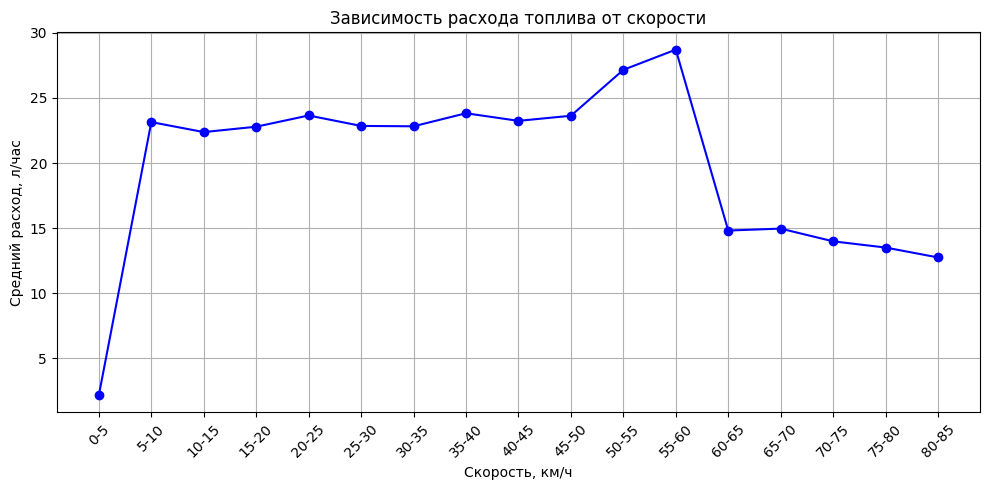

In [47]:
# Строим график зависимости топлива от скорости
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_by_interval.index, avg_by_interval.values, marker='o', linestyle='-', color='b')
ax.set_xlabel('Скорость, км/ч')
ax.set_ylabel('Средний расход, л/час')
ax.set_title('Зависимость расхода топлива от скорости')
ax.grid(True)

# Поворачиваем подписи по оси X
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

### Промежуточный вывод по поиску оптимальной скорости:
- Диапазон скоростей разбит на интервалы с шагом 5 км/ч от 0 до 85 км/ч.
- Средний расход в каждом интервале вычислен как среднее арифметическое значений Расход_л_час (литров в час) для всех точек, попавших в интервал.
- График наглядно демонстрирует, что расход топлива в час минимален при скоростях 0–5 км/ч (2.16 л/час), что соответствует режиму холостого хода или очень медленному движению. Далее расход резко возрастает до 28 л/час в диапазоне 50–60 км/ч, а затем снижается до 12.7 л/час на скоростях 80–85 км/ч - это объясняется повышением эффективности двигателя на высоких скоростях (меньше времени на преодоление того же расстояния).
- **Вывод по оптимальной скорости:**
  - Наиболее экономичный режим по расходу в час - стояние или очень медленное движение (холостой ход).
  - Для движения по трассе оптимальной с точки зрения расхода в час является скорость 80–85 км/ч (12.7 л/час), что может быть связано с работой двигателя в зоне максимальной эффективности.

## Задание 6. Холостой ход

Найдём машину, которая больше всего времени провела на холостом ходу

In [48]:
# Рассчитываем разницу в секундах между соседними точками
df['delta_t'] = df.groupby('ТС')['Дата и время'].diff().dt.total_seconds().fillna(0)

# Фильтруем машины с холостым ходом, группируем по ТС и суммируем время в часах
idle_hours = df[df['Режим'] == 'холостой'].groupby('ТС')['delta_t'].sum() / 3600

# Машина с максимальным временем
top_idle_car = idle_hours.idxmax()
top_idle_time = idle_hours.max()

# Выводим результат
print(f'Машина с максимальным временем холостого хода: {top_idle_car}')
print(f'Время: {top_idle_time:.2f} ч')

Машина с максимальным временем холостого хода: Shacman Т - р159ов
Время: 5.72 ч


Посчитаем общее время холостого хода в часах

In [49]:
# Общее время холостого хода по всем машинам
total_idle = idle_hours.sum()

# Выводим результат
print(f"Общее время холостого хода (все машины): {total_idle:.2f} ч")

Общее время холостого хода (все машины): 17.90 ч


**Расчитаем перерасход топлива по формуле:**
- Перерасход_топлива = Время_холостого_хода × Норма_холостой

In [50]:
# Берём норму расхода топлива на холостом ходу для машины, которая провела больше всего времени на холостом ходу
norm = norm_idle[top_idle_car]

# Считаем перерасход топлива для этой машины
overuse = top_idle_time * norm

# Выводим результат
print(f'Норма холостого хода: {norm:.2f} л/ч')
print(f'Перерасход топлива: {overuse:.2f} л')

Норма холостого хода: 2.60 л/ч
Перерасход топлива: 14.87 л


### Промежуточный вывод по холостому ходу:
- Отфильтрованы строки, соответствующие режиму «холостой ход» (Скорость = 0 и Обороты > 0).
- Для каждой машины суммарное время холостого хода пересчитано в часы (сумма delta_t / 3600).
- Определена машина-рекордсмен:
    - Shacman Т - р159ов - 5.72 часов холостого хода.
- Общее время холостого хода по всем машинам составило 17.90 часов.
- Для машины-рекордсмена из справочника взята норма расхода топлива на холостом ходу (2.60 л/ч), и рассчитан перерасход топлива:
    - 5.72 ч × 2.60 л/ч = 14.87 л.

## Задание 7. Автоматизация

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

def generate_fuel_report(input_file, output_file):
    # Загружаем оба листа в отдельные датасеты
    df = pd.read_excel(input_file, sheet_name='GPS_данные')
    df_norm = pd.read_excel(input_file, sheet_name='Нормативы')

    # Разведка и очистка данных
    text_cols = df.select_dtypes(include=['object']).columns # Фильтруем текстовый тип данных
    df[text_cols] = df[text_cols].apply(lambda x: x.str.strip()) # Удаляем возможные пробелы в словах
    df = df.replace('', pd.NA) # Заменим пустые строки на NaN
    df['Дата и время'] = df['Дата и время'].str.replace('/', '.') # Заменяем все слеши на точки в столбце с датой
    df['Дата и время'] = pd.to_datetime(df['Дата и время'], format='%d.%m.%Y %H:%M:%S', errors='coerce') # Преобразуем в datetime
    df = df.dropna(subset=['Дата и время']) # Удаляем все строки, где столбец 'Дата и время' равна NaN
    df = df.dropna(subset=['Обороты']) # Удаляем все строки, где столбец 'Обороты' равна NaN
    df = df.drop_duplicates() # Удаляем полные дубликаты

    
    # Преобразование координат
    # функция для преобразования координат
    def convert_coordinates_to_decimal(coord_str):
        try:
            parts = str(coord_str).strip().split('°')
            degrees = float(parts[0].strip())
            minutes = float(parts[1].strip().replace("'", "").strip())
            return degrees + minutes / 60.0
        except:
            return None

    df['Широта'] = df['Широта'].apply(convert_coordinates_to_decimal)
    df['Долгота'] = df['Долгота'].apply(convert_coordinates_to_decimal)

    
    # Расчёт пробега
    # Функция гаверсинуса
    def haversine(lat1, lon1, lat2, lon2):
        # Переводим градусы в радианы
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

        # Подготавливаем значения для формулы (Δlat, Δlon)
        dlat = lat2 - lat1
        dlon = lon2 - lon1

        # Делаем вычисления по формуле
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        d = 6371 * c
        return d
    
    df = df.sort_values(['ТС', 'Дата и время']).reset_index(drop=True) # Сортируем данные
    
    # Получаем координаты предыдущей точки для каждого ТС
    df['prev_lat'] = df.groupby('ТС')['Широта'].shift(1)
    df['prev_lon'] = df.groupby('ТС')['Долгота'].shift(1)

    # Функция для вычисления расстояния
    def calc_distance(row):
        if pd.isna(row['prev_lat']):
            return 0.0
        return haversine(row['Широта'], row['Долгота'], row['prev_lat'], row['prev_lon'])

    df['Расстояние_до_предыдущей_км'] = df.apply(calc_distance, axis=1)

    # Удаляем временные столбцы с предыдущими координатами
    df.drop(['prev_lat', 'prev_lon'], axis=1, inplace=True)

    df['Дата'] = df['Дата и время'].dt.date

    # Считаем общий пробег за день
    df['Дневной_пробег'] = df.groupby(['ТС', 'Дата'])['Расстояние_до_предыдущей_км'].transform('sum')

    # Считаем среднюю скорость движения (только где скорость > 0)
    df['Средняя_скорость'] = df.groupby(['ТС', 'Дата'])['Скорость'].transform(lambda x: x[x > 0].mean())

    
    # Анализ расхода топлива
    # Определяем режим движения
    df['Режим'] = 'движение' # По умолчанию ставим режим'движение'
    df.loc[(df['Скорость'] == 0) & (df['Обороты'] > 0), 'Режим'] = 'холостой' # определяем условия для холостого режима движения

    df['Тип_трассы'] = None # Создаём столбец 'Тип_трассы' со значением None для всех строк
    df.loc[df['Режим'] == 'движение', 'Тип_трассы'] = 'город' # Для всех движений по умолчанию ставим 'город'
    df.loc[(df['Режим'] == 'движение') & (df['Скорость'] >= 60), 'Тип_трассы'] = 'трасса' # по условию перезаписываем 'город' на 'трасса'

    # Создаём словарь с нормами расхода топлива для разных режимов работы
    norm_idle = dict(zip(df_norm['ТС'], df_norm['Норма_холостой']))
    norm_city = dict(zip(df_norm['ТС'], df_norm['Норма_город']))
    norm_highway = dict(zip(df_norm['ТС'], df_norm['Норма_трасса']))
    
    # Интервал времени между точками (сек)
    df['delta_t'] = df.groupby('ТС')['Дата и время'].diff().dt.total_seconds().fillna(0)

    # Расход за интервал
    df['Расход_интервал'] = 0.0 # Создаём столбец 'Расход_интервал' и заполняем нулями 

    mask_idle = df['Режим'] == 'холостой' # Маска для холостого хода

    # Расчитываем расход топлива для холостого хода
    df.loc[mask_idle, 'Расход_интервал'] = df.loc[mask_idle, 'ТС'].map(norm_idle) * (df.loc[mask_idle, 'delta_t'] / 3600)

    mask_city = (df['Режим'] == 'движение') & (df['Тип_трассы'] == 'город') # Маска для движения в городе

    # Расчитываем расход топлива для города
    df.loc[mask_city, 'Расход_интервал'] = (
        df.loc[mask_city, 'ТС'].map(norm_city) * (df.loc[mask_city, 'Обороты'] / 1500) * (df.loc[mask_city, 'delta_t'] / 3600)
    )

    mask_highway = (df['Режим'] == 'движение') & (df['Тип_трассы'] == 'трасса') # Маска для движения на трассе

    # Рассчитываем эффективность
    efficiency = 1 - np.abs(df.loc[mask_highway, 'Скорость'] - 65) / 100
    
    # Расчитываем расход топлива для трассы
    df.loc[mask_highway, 'Расход_интервал'] = (
        df.loc[mask_highway, 'ТС'].map(norm_highway) * (df.loc[mask_highway, 'Обороты'] / 1500) * efficiency * (df.loc[mask_highway, 'delta_t'] / 3600)
    )
    
    # Группируем по машине и дате и суммируем расход топлива за интервалы, чтобы получить расчётный расход за день
    df['Расчётный_расход'] = df.groupby(['ТС', 'Дата'])['Расход_интервал'].transform('sum')

    # Берём начальный уровень топлива
    df['Уровень_топлива_первый'] = df.groupby(['ТС', 'Дата'])['Уровень топлива'].transform('first')

    # Берём конечный уровень топлива
    df['Уровень_топлива_последний'] = df.groupby(['ТС', 'Дата'])['Уровень топлива'].transform('last')

    # Вычисляем разницу между начальным и конечным уровнем топлива за день.
    df['Фактический_расход'] = df['Уровень_топлива_первый'] - df['Уровень_топлива_последний']

    # Рассчитываем относительное отклонение в процентах
    df['Отклонение_%'] = (
        np.abs(df['Расчётный_расход'] - df['Фактический_расход']) / df['Фактический_расход'] * 100
    )
    
    # Поиск оптимальной скорости
    # Добавляем колонку расхода в л/час
    df['Расход_л_час'] = 0.0
    mask_delta_t  = df['delta_t'] > 0
    df.loc[mask_delta_t, 'Расход_л_час'] = df.loc[mask_delta_t, 'Расход_интервал'] * 3600 / delta_t[mask_delta_t]
   
    bins = list(range(0, 86, 5)) # Выделяем границы интервалов
    labels = [f'{i}-{i+5}' for i in bins[:-1]] # Создаём наименования для интервалов
    df['Интервалы_скорости'] = pd.cut(df['Скорость'], bins=bins, labels=labels, right=False) # Разбиваем значения на интервалы
    
    # Средний расход топлива по интервалам
    avg_by_interval = df.groupby('Интервалы_скорости', observed=False)['Расход_л_час'].mean().dropna()
    if not avg_by_interval.empty:
        min_int = avg_by_interval.idxmin()
        min_val = avg_by_interval.min()
        opt_speed_df = pd.DataFrame({
            'Интервал': avg_by_interval.index,
            'Средний_расход_л_час': avg_by_interval.values
        })
        opt_speed_df = opt_speed_df.sort_values('Средний_расход_л_час')
    else:
        opt_speed_df = pd.DataFrame(columns=['Интервал', 'Средний_расход_л_час'])
  
    # Холостой ход
    # Фильтруем машины с холостым ходом, группируем по ТС и суммируем время в часах
    idle_hours = df[df['Режим'] == 'холостой'].groupby('ТС')['delta_t'].sum() / 3600

    # Машина с максимальным временем
    top_idle_car = idle_hours.idxmax() if not idle_hours.empty else None
    top_idle_time = idle_hours.max() if not idle_hours.empty else 0.0

    # Общее время холостого хода по всем машинам
    total_idle = idle_hours.sum()

    # Берём норму расхода топлива на холостом ходу для машины, которая провела больше всего времени на холостом ходу
    norm = norm_idle[top_idle_car]

    # Считаем перерасход топлива для этой машины
    overuse = top_idle_time * norm

    # Формирование листов для Excel
    summary = df[['ТС', 'Дата', 'Дневной_пробег', 'Средняя_скорость',
                  'Расчётный_расход', 'Фактический_расход', 'Отклонение_%']].drop_duplicates()
    summary = summary.sort_values(['ТС', 'Дата'])

    details = df[['ТС', 'Дата и время', 'Широта', 'Долгота', 'Скорость', 'Обороты',
                  'Уровень топлива', 'Расстояние_до_предыдущей_км', 'Дневной_пробег',
                  'Средняя_скорость', 'Режим', 'Тип_трассы', 'Расход_интервал',
                  'Расчётный_расход', 'Фактический_расход', 'Отклонение_%']].copy()

    anomalies = df[df['Отклонение_%'] > 30].copy()
    if not anomalies.empty:
        anomalies['тип_аномалии'] = 'Отклонение расхода > 30%'
        anomalies = anomalies[['ТС', 'Дата', 'Расчётный_расход', 'Фактический_расход',
                               'Отклонение_%', 'тип_аномалии']].drop_duplicates()
        anomalies = anomalies.sort_values('Отклонение_%', ascending=False)
    else:
        anomalies = pd.DataFrame(columns=['ТС', 'Дата', 'Расчётный_расход',
                                          'Фактический_расход', 'Отклонение_%', 'тип_аномалии'])

    # Сохранение в Excel
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        summary.to_excel(writer, sheet_name='Сводка по ТС', index=False)
        details.to_excel(writer, sheet_name='Детализация', index=False)
        anomalies.to_excel(writer, sheet_name='Аномалии', index=False)

    print(f'Результат сохранён в {output_file}')

# Запуск
if __name__ == "__main__":
    input_file = "Исходные данные.xlsx"
    output_file = "Результат_анализа.xlsx"
    generate_fuel_report(input_file, output_file)

Результат сохранён в Результат_анализа.xlsx
